# Cross-validation of base models

Compares four image models with **5-fold patient-grouped cross-validation**, on the same folds:

| Model | Backbone | Head | Trained |
|---|---|---|---|
| **Scratch CNN** | small CNN (4 conv blocks), random init | GAP → Dropout → Dense(1) | everything, from scratch |
| **ResNet50 + linear** | ResNet50, ImageNet, frozen | Dropout → Dense(1) | head only |
| **DenseNet121 + linear** | DenseNet121, ImageNet, frozen | Dropout → Dense(1) | head only |
| **ResNet50 fine-tuned + linear** | ResNet50, ImageNet, last block unfrozen | Dropout → Dense(1) | head, then head + `conv5_block3` |

Reported per model: **ROC-AUC** and **PR-AUC** on each held-out fold, summarised as mean ± std across the
5 folds. PR-AUC is the more telling one here: with ~1.8% melanoma, a random model scores ROC-AUC 0.5 but
PR-AUC only ~0.018.

**Data:** the 10%-margin lesion crops of `training_set.csv` only. `validation_set.csv` and the test set are
never loaded, so they stay unseen for the fusion model and the final evaluation.

**Fairness: kept identical for every model**

| | |
|---|---|
| Folds and seeds | the same 5 patient-grouped folds; the same seed per fold |
| Data per fold | the same fit / early-stop / held-out split (below) |
| Augmentation + imbalance | online augmentation, 70/30 oversampling, balanced class weights at that mix |
| Optimiser | Adam, learning rate 1e-3 for anything trained from its starting point |
| Early stopping | the same rule: val AUC on the **early-stop split**, patience 5, cap 50 epochs, best epoch restored |
| Scoring | ROC-AUC / PR-AUC on the **held-out fold only**, which no model ever uses to choose anything |

Each fold's training patients are split again (80/20, by patient) into a **fit** part and an **early-stop**
part. Early stopping (and the fine-tuning keep-or-revert decision) only ever looks at the early-stop part, so
a model that gets more epochs, or two training phases, can't get an optimistic score by picking its luckiest
epoch on the fold it's scored on.

**What legitimately differs:** the architecture, each backbone's own preprocessing, and the fine-tuned model's
second phase (that phase is what's being tested). No model's hyperparameters were tuned on these folds -- see
the note in the setup section.

Each (model, fold) result is saved as soon as it finishes, so an interrupted run resumes where it stopped.

In [1]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so results are reproducible run-to-run --
# TensorFlow's own RNG (weight init) and GPU op-level determinism need pinning
# separately from numpy/sklearn: cuDNN picks nondeterministic algorithms by default.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

On a **Colab kernel**, upload `melanoma_data.zip` to your Google Drive once; this cell mounts Drive and
unzips it into `/content` each session (falls back to a directly-uploaded `/content/melanoma_data.zip`).
No-op locally.

In [2]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

Mounted at /content/drive
data ready in /content


In [3]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as the
# working directory, which breaks every relative path below -- hop into this notebook's
# own folder if we're not already there (and not on Colab, which uses /content).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Labels

In [4]:
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order (and so every fold split) is identical across machines/runs
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})
labels_df = pd.read_csv('train_labels.csv')
image_df = files_df.merge(labels_df, on='image_name', how='inner')[['image_name', 'patient_id', 'image_path', 'target']]

print(f'{len(image_df)} labelled images, {image_df["patient_id"].nunique()} patients, '
      f'{int(image_df["target"].sum())} malignant ({image_df["target"].mean():.2%})')

6864 labelled images, 422 patients, 128 malignant (1.86%)


### Training / validation split files

`training_set.csv` / `validation_set.csv` list `image_name` only -- the shared, pre-defined, patient-grouped
split used by all three models. On Colab they aren't in `melanoma_data.zip`, so this reuses a copy from Drive
if there is one, otherwise prompts an upload.

In [5]:
import shutil

SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    for f in SPLIT_FILES:
        if not os.path.exists(f) and os.path.exists(os.path.join(DRIVE_SPLIT_DIR, f)):
            shutil.copy(os.path.join(DRIVE_SPLIT_DIR, f), f)
            print(f'copied {f} from Google Drive')
    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

copied training_set.csv from Google Drive
copied validation_set.csv from Google Drive


In [ ]:
train_df = image_df.merge(pd.read_csv('training_set.csv'), on='image_name', how='inner').reset_index(drop=True)
val_df = image_df.merge(pd.read_csv('validation_set.csv'), on='image_name', how='inner').reset_index(drop=True)

assert len(train_df) == len(pd.read_csv('training_set.csv')), 'some training_set.csv image_names not found'
assert len(val_df) == len(pd.read_csv('validation_set.csv')), 'some validation_set.csv image_names not found'
assert not (set(train_df['patient_id']) & set(val_df['patient_id'])), 'patient leakage between training/validation!'

for name, df in [('training', train_df), ('validation', val_df)]:
    print(f'{name:10s}: {len(df)} images, {df["patient_id"].nunique()} patients, '
          f'benign={int((df["target"] == 0).sum())}, malignant={int(df["target"].sum())}')

training  : 5629 images, 337 patients, benign=5526, malignant=103
validation: 1235 images, 85 patients, benign=1210, malignant=25


## Cropped images (10% margin)

Restores `train_cropped_margin_0.10/` from `melanoma_cropped_margin_0.10.zip` (local, then Drive). These
crops are generated by `Crop_margin_ablation.ipynb` -- run that first if no zip exists yet.

In [7]:
import zipfile

IMG_SIZE = 224
CROP_MARGIN = 0.10
CROPPED_DIR = 'train_cropped_margin_0.10'
CROPPED_ZIP = 'melanoma_cropped_margin_0.10.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped_margin_0.10.zip'

if not os.path.isdir(CROPPED_DIR) or not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip is None:
        raise FileNotFoundError(
            f'{CROPPED_DIR}/ not found and no {CROPPED_ZIP} locally or at {DRIVE_CROPPED_ZIP} -- '
            'run Crop_margin_ablation.ipynb first to generate the 10%-margin crops')
    os.makedirs(CROPPED_DIR, exist_ok=True)
    get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
    print(f'restored crops from {cached_zip}')

# Every labelled image needs a same-filename crop (junk like .DS_Store / __MACOSX is ignored)
crop_files = {f for f in os.listdir(CROPPED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
missing = sorted({os.path.basename(p) for p in image_df['image_path']} - crop_files)
assert not missing, f'{len(missing)} images have no crop in {CROPPED_DIR}/, e.g. {missing[:5]}'
print(f'{len(crop_files)} crops in {CROPPED_DIR}/ -- every labelled image covered')

restored crops from /content/drive/MyDrive/melanoma_cropped_margin_0.10.zip
6864 crops in train_cropped_margin_0.10/ -- every labelled image covered


In [8]:
def load_images(paths, image_dir, img_size=IMG_SIZE):
    """Loads the same-filename image from image_dir for every path, as uint8 RGB."""
    X = np.empty((len(paths), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(paths):
        with Image.open(os.path.join(image_dir, os.path.basename(path))) as img:
            X[i] = np.array(img.convert('RGB').resize((img_size, img_size)))
    return X

In [9]:
# Training set only -- validation_set.csv and the test set are never loaded in this notebook
X = load_images(train_df['image_path'], CROPPED_DIR)
y = train_df['target'].to_numpy().astype(int)
groups = train_df['patient_id'].to_numpy()
print('training set:', X.shape, f'{X.nbytes / 1e6:.0f} MB', f'| {y.sum()} malignant ({y.mean():.2%})')

training set: (5629, 224, 224, 3) 847 MB | 103 malignant (1.83%)


## Augmentation

Same `melanoma_augment` recipe as `Basic_CNN_model.ipynb`: no hue/saturation shifts (pigment colour is
diagnostic), mirrored borders instead of black wedges, no zoom/warp (images are already cropped to the
lesion), and a small CoarseDropout box. Applied **online** to oversampled malignant images only -- a fresh
random transform every epoch.

In [10]:
import albumentations as A
import cv2

melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Shared training setup

One data pipeline for all four models, parameterised only by the backbone's own preprocessing:

- **Scratch CNN:** raw 0-255 pixels, rescaled to 0-1 inside the model.
- **ResNet50:** `resnet50.preprocess_input` (RGB→BGR + ImageNet mean subtraction).
- **DenseNet121:** `densenet.preprocess_input` (0-1 scaling + ImageNet mean/std).

Linear heads are `Dropout(0.3)` → `Dense(1, sigmoid)` with L2 = 1e-3, identical for all three pretrained models.

**Hyperparameters are fixed, not tuned per model.** Every model gets reasonable defaults and the same learning
rate and early-stopping rule, with no per-model search -- so no model gets a bigger tuning budget than another.
The flip side: none is at its personal best, so read the comparison as "out-of-the-box performance under one
shared recipe". (The ResNet50 + MLP grid in `Basic_CNN_model.ipynb` is *not* used here for that reason -- it
would give ResNet an advantage the other models didn't get.)

In [11]:
import math
import shutil
import time
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold

# ---- Shared by every model (the fairness-critical settings) ----
N_FOLDS = 5
BATCH_SIZE = 32
TARGET_MINORITY_RATIO = 0.3       # oversample malignant to a 70/30 benign/malignant mix
CLASS_WEIGHT_BLEND = 1.0          # 1.0 = fully 'balanced' class weights at that mix
LEARNING_RATE = 1e-3              # Adam, for every model trained from its starting point
MAX_EPOCHS = 50                   # generous cap -- early stopping decides, not the cap
PATIENCE = 5                      # same early-stopping rule for every model (on the early-stop split)
EARLY_STOP_FRACTION = 0.2         # share of each fold's training patients held back for early stopping

# ---- Linear heads (ResNet50 / DenseNet121 / fine-tuned ResNet50) -- identical for all three ----
LINEAR_DROPOUT = 0.3
LINEAR_L2 = 1e-3

# ---- Fine-tuning phase 2 (the thing being tested for model 4) ----
FT_UNFREEZE_PREFIX = 'conv5_block3_'   # last ResNet50 bottleneck block (~4.5M weights)
FT_LR = 1e-5                           # 100x lower, standard for fine-tuning pretrained weights

# ---- Scratch CNN architecture ----
SCRATCH_FILTERS = [32, 64, 128, 256]
SCRATCH_DROPOUT = 0.4
SCRATCH_L2 = 1e-4

identity_preprocess = lambda x: x   # scratch CNN rescales inside the model


def make_dataset(images, labels=None, preprocess=identity_preprocess, batch_size=BATCH_SIZE):
    """uint8 images -> float32 -> backbone preprocessing, streamed in batches."""
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: preprocess(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, lbl: (preprocess(tf.cast(x, tf.float32)), lbl)
    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def make_training_dataset(images, labels, preprocess, seed, ratio=TARGET_MINORITY_RATIO, batch_size=BATCH_SIZE):
    """Originals + malignant images oversampled by index to `ratio`; every oversampled copy gets a
    fresh random melanoma_augment transform each epoch."""
    rng = np.random.default_rng(seed)
    minority_idx = np.where(labels == 1)[0]
    n_benign = len(labels) - len(minority_idx)
    n_target = max(len(minority_idx), int(round(n_benign * ratio / (1 - ratio))))
    extra_idx = rng.choice(minority_idx, size=n_target - len(minority_idx), replace=True)

    def augment(image, label):
        aug = tf.py_function(lambda img: melanoma_augment(image=img.numpy())['image'], [image], tf.uint8)
        aug.set_shape(image.shape)
        return preprocess(tf.cast(aug, tf.float32)), label

    base_ds = tf.data.Dataset.from_tensor_slices((images, labels)).map(
        lambda img, lbl: (preprocess(tf.cast(img, tf.float32)), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    extra_ds = tf.data.Dataset.from_tensor_slices((images[extra_idx], labels[extra_idx])).map(
        augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = base_ds.concatenate(extra_ds).shuffle(len(images) + len(extra_idx), seed=seed,
                                               reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def blended_class_weight(labels, ratio=TARGET_MINORITY_RATIO, blend=CLASS_WEIGHT_BLEND):
    n_benign = int((labels == 0).sum())
    n_mal = max(int((labels == 1).sum()), int(round(n_benign * ratio / (1 - ratio))))
    mix = np.concatenate([np.zeros(n_benign, dtype=int), np.ones(n_mal, dtype=int)])
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=mix)
    return {k: 1.0 + blend * (v - 1.0) for k, v in enumerate(w)}


def compile_binary(model, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.AUC(name='pr_auc', curve='PR')])
    return model

## The four models

**Scratch CNN.** Four conv blocks (`Conv 3×3 → BatchNorm → ReLU`, twice, then `MaxPool`), with 32 → 64 → 128 →
256 filters, global average pooling, dropout and a sigmoid output (~1.2M weights). Small on purpose: with ~65
malignant images per fit split, a big network trained from random weights would just memorise them. It gets
the same early-stopping rule and epoch cap as everyone else -- the 50-epoch cap leaves room for its slower
start without giving it extra patience.

**Frozen backbone + linear head** (ResNet50, DenseNet121). The backbone runs in inference mode and only
`Dropout → Dense(1)` trains -- how good are the ImageNet features on their own?

**ResNet50 fine-tuned + linear head.** Two phases per fold:
1. Train the linear head on the frozen backbone (identical to ResNet50 + linear).
2. Unfreeze the last bottleneck block (`conv5_block3`, BatchNorm kept frozen) and continue at a 100× lower
   learning rate, with the same early-stopping rule. If phase 2 never beats phase 1's best early-stop AUC,
   the phase-1 weights are kept -- so fine-tuning can't make the model worse than its own frozen version.

The difference between models 2 and 4 shows exactly what fine-tuning adds.

In [12]:
def build_scratch_cnn():
    reg = tf.keras.regularizers.l2(SCRATCH_L2)
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    for filters in SCRATCH_FILTERS:
        for _ in range(2):
            x = layers.Conv2D(filters, 3, padding='same', use_bias=False, kernel_regularizer=reg)(x)
            x = layers.BatchNormalization()(x)
            x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(SCRATCH_DROPOUT)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg)(x)
    return compile_binary(models.Model(inputs, outputs, name='scratch_cnn'), LEARNING_RATE)


def build_frozen_linear(backbone_fn):
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)            # BatchNorm always in inference mode
    x = layers.Dropout(LINEAR_DROPOUT)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(LINEAR_L2))(x)
    return compile_binary(models.Model(inputs, outputs), LEARNING_RATE), base


def unfreeze_last_block(model, base):
    base.trainable = True
    for layer in base.layers:
        layer.trainable = layer.name.startswith(FT_UNFREEZE_PREFIX) and not isinstance(layer, layers.BatchNormalization)
    return compile_binary(model, FT_LR)   # recompile so the new trainable set + learning rate take effect


def fit_with_early_stopping(model, train_ds, stop_ds, class_weight):
    """Same rule for every model: val AUC on the early-stop split, patience PATIENCE, cap MAX_EPOCHS,
    best epoch's weights restored. Returns (best epoch, best early-stop AUC)."""
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                                  restore_best_weights=True)
    history = model.fit(train_ds, validation_data=stop_ds, epochs=MAX_EPOCHS, class_weight=class_weight,
                        callbacks=[early_stop], verbose=2)
    # restore_best_weights only kicks in when training actually stops early
    if early_stop.best_weights is not None:
        model.set_weights(early_stop.best_weights)
    return int(np.argmax(history.history['val_auc'])) + 1, float(max(history.history['val_auc']))


def run_fold(model_name, X_fit, y_fit, X_stop, y_stop, X_heldout, seed):
    """Trains one model on the fit split, early-stops on the early-stop split, and returns its
    probabilities on the held-out fold (never used for any decision) plus an info dict."""
    class_weight = blended_class_weight(y_fit)
    if model_name == 'Scratch CNN':
        preprocess = identity_preprocess
        model = build_scratch_cnn()
        best, best_auc = fit_with_early_stopping(model, make_training_dataset(X_fit, y_fit, preprocess, seed),
                                                 make_dataset(X_stop, y_stop, preprocess), class_weight)
        info = {'best_epoch': best, 'early_stop_auc': best_auc}
    elif model_name in ('ResNet50 + linear', 'DenseNet121 + linear', 'ResNet50 fine-tuned + linear'):
        backbone_fn, preprocess = ((DenseNet121, densenet_preprocess) if model_name.startswith('DenseNet')
                                   else (ResNet50, resnet_preprocess))
        model, base = build_frozen_linear(backbone_fn)
        train_ds = make_training_dataset(X_fit, y_fit, preprocess, seed)
        stop_ds = make_dataset(X_stop, y_stop, preprocess)
        best, best_auc = fit_with_early_stopping(model, train_ds, stop_ds, class_weight)
        info = {'best_epoch': best, 'early_stop_auc': best_auc}
        if model_name == 'ResNet50 fine-tuned + linear':
            phase1_weights = model.get_weights()
            unfreeze_last_block(model, base)
            best_ft, best_ft_auc = fit_with_early_stopping(model, train_ds, stop_ds, class_weight)
            kept = 'phase 2' if best_ft_auc > best_auc else 'phase 1'
            if kept == 'phase 1':   # fine-tuning didn't beat the frozen head on the early-stop split
                model.set_weights(phase1_weights)
            info.update({'best_epoch_finetune': best_ft, 'early_stop_auc_finetune': best_ft_auc,
                         'finetune_kept': kept})
            print(f'fine-tuning: early-stop AUC {best_auc:.4f} -> {best_ft_auc:.4f}, keeping {kept}')
    else:
        raise ValueError(model_name)
    prob = model.predict(make_dataset(X_heldout, preprocess=preprocess), verbose=0).ravel()
    return prob, info

## 5-fold patient-grouped CV

`StratifiedGroupKFold` keeps each patient in a single fold, with a similar malignant rate per fold. Each
fold's training patients are then split again by patient:

| Part | Share of the training set | Used for |
|---|---|---|
| **fit** | ~64% | training |
| **early-stop** | ~16% | early stopping, and the fine-tuning keep-or-revert decision |
| **held-out fold** | 20% | the reported ROC-AUC / PR-AUC -- never used for any decision |

Every model uses exactly these splits, so the per-fold results are **paired** across models.

In [13]:
splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
stop_splitter = StratifiedGroupKFold(n_splits=round(1 / EARLY_STOP_FRACTION), shuffle=True, random_state=SEED)
folds = []
for fold, (tr_idx, va_idx) in enumerate(splitter.split(train_df, y, groups=groups), start=1):
    fit_rel, stop_rel = next(stop_splitter.split(tr_idx, y[tr_idx], groups=groups[tr_idx]))
    fit_idx, stop_idx = tr_idx[fit_rel], tr_idx[stop_rel]
    for a, b in [(fit_idx, stop_idx), (fit_idx, va_idx), (stop_idx, va_idx)]:
        assert not (set(groups[a]) & set(groups[b])), f'fold {fold}: patient leakage'
    folds.append({'fold': fold, 'fit': fit_idx, 'stop': stop_idx, 'val': va_idx})
    print(f'fold {fold}: fit {len(fit_idx)} ({y[fit_idx].sum()} mal) | early-stop {len(stop_idx)} '
          f'({y[stop_idx].sum()} mal) | held-out {len(va_idx)} ({y[va_idx].sum()} mal)')

fold 1: fit 3752 (66 mal) | early-stop 689 (18 mal) | held-out 1188 (19 mal)
fold 2: fit 3473 (63 mal) | early-stop 930 (18 mal) | held-out 1226 (22 mal)
fold 3: fit 3781 (55 mal) | early-stop 840 (29 mal) | held-out 1008 (19 mal)
fold 4: fit 3393 (61 mal) | early-stop 1180 (16 mal) | held-out 1056 (26 mal)
fold 5: fit 3582 (70 mal) | early-stop 896 (16 mal) | held-out 1151 (17 mal)


### Run the CV

`MODELS_TO_RUN` picks which models train (all four by default; roughly ordered fastest → slowest). Results go to
`cv_base_models_results.csv` (one row per model × fold) and `cv_base_models_oof.csv` (held-out probabilities
per image) after every single fold, also copied to Drive. Re-running skips anything already in the CSVs, so a
disconnect costs at most one fold. Delete the CSVs to start over after changing a setting.

Rough cost on a Colab GPU: the frozen-backbone models still run the full backbone every epoch (because of the
online augmentation), and fine-tuning adds a second phase, so expect the whole run to take a few hours.

In [14]:
MODELS_TO_RUN = ['ResNet50 + linear', 'DenseNet121 + linear', 'Scratch CNN', 'ResNet50 fine-tuned + linear']

RESULTS_CSV = 'cv_base_models_results.csv'
OOF_CSV = 'cv_base_models_oof.csv'
DRIVE_DIR = '/content/drive/MyDrive'


def load_csv(name):
    path = next((p for p in (name, os.path.join(DRIVE_DIR, name)) if os.path.exists(p)), None)
    return pd.read_csv(path) if path else pd.DataFrame()


def save_csv(df, name):
    df.to_csv(name, index=False)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(name, os.path.join(DRIVE_DIR, name))


results = load_csv(RESULTS_CSV)
oof = load_csv(OOF_CSV)
done = set(zip(results['model'], results['fold'])) if len(results) else set()
print(f'{len(done)} (model, fold) runs already done')

for model_name in MODELS_TO_RUN:
    for f in folds:
        if (model_name, f['fold']) in done:
            continue
        t0 = time.time()
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED + f['fold'])
        print(f"\n=== {model_name} | fold {f['fold']} ===")
        prob, info = run_fold(model_name, X[f['fit']], y[f['fit']], X[f['stop']], y[f['stop']], X[f['val']],
                              seed=SEED + f['fold'])
        y_va = y[f['val']]
        row = {'model': model_name, 'fold': f['fold'],
               'roc_auc': roc_auc_score(y_va, prob), 'pr_auc': average_precision_score(y_va, prob),
               'n_val': len(y_va), 'n_val_malignant': int(y_va.sum()),
               'minutes': round((time.time() - t0) / 60, 1), **info}
        results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
        oof = pd.concat([oof, pd.DataFrame({'model': model_name, 'fold': f['fold'],
                                            'image_name': train_df['image_name'].to_numpy()[f['val']],
                                            'target': y_va, 'probability': prob})], ignore_index=True)
        save_csv(results, RESULTS_CSV)
        save_csv(oof, OOF_CSV)
        print(f"{model_name} | fold {f['fold']}: ROC-AUC {row['roc_auc']:.4f}, PR-AUC {row['pr_auc']:.4f} "
              f"({row['minutes']} min)")

display(results.sort_values(['model', 'fold']).round(4))

16 (model, fold) runs already done

=== ResNet50 fine-tuned + linear | fold 2 ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/50
153/153 - 37s - 244ms/step - auc: 0.9306 - loss: 0.3296 - pr_auc: 0.8932 - val_auc: 0.8538 - val_loss: 0.2090 - val_pr_auc: 0.1334
Epoch 2/50
153/153 - 23s - 148ms/step - auc: 0.9721 - loss: 0.2104 - pr_auc: 0.9551 - val_auc: 0.8587 - val_loss: 0.2029 - val_pr_auc: 0.1424
Epoch 3/50
153/153 - 23s - 147ms/step - auc: 0.9839 - loss: 0.1667 - pr_auc: 0.9717 - val_auc: 0.8547 - val_loss: 0.1033 - val_pr_auc: 0.1299
Epoch 4/50
153/153 - 23s - 148ms/step - auc: 0.9859 - loss: 0.1575 - pr_auc: 0.9750 - val_auc: 0.8602 - val_loss: 0.1531 - val_pr_auc: 0.1412
Epoch 5/50
153/153 - 22s - 147ms/step - auc: 0.9878 - loss: 0.1428 - pr_auc: 0.9793 - val_auc: 0.8679 - val_loss: 0.1410 - val_pr_auc: 0.1382
Epoch 6/50
153/153 - 23s - 147ms/step - auc: 0.9876 - loss: 0.1463 - pr_auc: 0.9778 - val_auc: 0.8720 - val_loss: 0.1549 - val_pr_auc: 0.1394
Epoch 7/50
153/

,model,fold,roc_auc,pr_auc,n_val,n_val_malignant,minutes,best_epoch,early_stop_auc,best_epoch_finetune,early_stop_auc_finetune,finetune_kept
5,DenseNet121 + linear,1,0.7725,0.0688,1188,19,7.4,12,0.7950,NaN,NaN,NaN
6,DenseNet121 + linear,2,0.7241,0.0433,1226,22,9.0,17,0.8094,NaN,NaN,NaN
7,DenseNet121 + linear,3,0.7816,0.1306,1008,19,5.5,7,0.7583,NaN,NaN,NaN
8,DenseNet121 + linear,4,0.6514,0.0860,1056,26,6.7,11,0.8769,NaN,NaN,NaN
9,DenseNet121 + linear,5,0.8133,0.0839,1151,17,4.1,4,0.6979,NaN,NaN,NaN
0,ResNet50 + linear,1,0.8259,0.0838,1188,19,3.3,2,0.7968,NaN,NaN,NaN
1,ResNet50 + linear,2,0.6956,0.0536,1226,22,4.0,5,0.8736,NaN,NaN,NaN
2,ResNet50 + linear,3,0.7996,0.1342,1008,19,3.1,2,0.7856,NaN,NaN,NaN
3,ResNet50 + linear,4,0.7723,0.0933,1056,26,2.5,1,0.8431,NaN,NaN,NaN
4,ResNet50 + linear,5,0.8112,0.0979,1151,17,3.7,4,0.7518,NaN,NaN,NaN


## Results: CV ROC-AUC and CV PR-AUC

Mean ± std over the 5 held-out folds. **PR-AUC baseline** is the malignant rate (what a random model scores),
shown for reference. With ~20 melanomas per fold, differences smaller than about one std are not meaningful.

The held-out fold was never used to choose anything (epochs, fine-tuning keep/revert), so these are honest
estimates for every model. `finetune_kept` in the per-fold results shows how often fine-tuning actually beat
the frozen head on the early-stop split.

In [15]:
results = load_csv(RESULTS_CSV)
MODEL_ORDER = [m for m in ['Scratch CNN', 'ResNet50 + linear', 'DenseNet121 + linear', 'ResNet50 fine-tuned + linear']
               if m in set(results['model'])]

summary = (results.groupby('model')
           .agg(cv_roc_auc_mean=('roc_auc', 'mean'), cv_roc_auc_std=('roc_auc', 'std'),
                cv_pr_auc_mean=('pr_auc', 'mean'), cv_pr_auc_std=('pr_auc', 'std'),
                folds=('fold', 'count'), mean_best_epoch=('best_epoch', 'mean'))
           .reindex(MODEL_ORDER))
summary['CV ROC-AUC'] = summary.apply(lambda r: f"{r.cv_roc_auc_mean:.3f} ± {r.cv_roc_auc_std:.3f}", axis=1)
summary['CV PR-AUC'] = summary.apply(lambda r: f"{r.cv_pr_auc_mean:.3f} ± {r.cv_pr_auc_std:.3f}", axis=1)
display(summary[['CV ROC-AUC', 'CV PR-AUC', 'folds', 'mean_best_epoch']])
print(f'PR-AUC baseline (malignant rate): {y.mean():.3f}')
incomplete = summary.index[summary['folds'] < N_FOLDS].tolist()
if incomplete:
    print(f'not all folds done yet for: {incomplete}')

# Per-fold table (paired: same folds for every model)
display(results.pivot(index='fold', columns='model', values='roc_auc')[MODEL_ORDER].round(3)
        .rename(columns=lambda m: f'{m} ROC'))
display(results.pivot(index='fold', columns='model', values='pr_auc')[MODEL_ORDER].round(3)
        .rename(columns=lambda m: f'{m} PR'))

summary.to_csv('cv_base_models_summary.csv')

,CV ROC-AUC,CV PR-AUC,folds,mean_best_epoch
model,,,,
Scratch CNN,0.736 ± 0.123,0.071 ± 0.032,5,6.8
ResNet50 + linear,0.781 ± 0.052,0.093 ± 0.029,5,2.8
DenseNet121 + linear,0.749 ± 0.063,0.083 ± 0.032,5,10.2
ResNet50 fine-tuned + linear,0.779 ± 0.044,0.096 ± 0.023,5,2.2


PR-AUC baseline (malignant rate): 0.018


model,Scratch CNN ROC,ResNet50 + linear ROC,DenseNet121 + linear ROC,ResNet50 fine-tuned + linear ROC
fold,,,,
1,0.792,0.826,0.772,0.820
2,0.799,0.696,0.724,0.709
3,0.521,0.800,0.782,0.808
4,0.747,0.772,0.651,0.769
5,0.820,0.811,0.813,0.788


model,Scratch CNN PR,ResNet50 + linear PR,DenseNet121 + linear PR,ResNet50 fine-tuned + linear PR
fold,,,,
1,0.069,0.084,0.069,0.089
2,0.076,0.054,0.043,0.064
3,0.025,0.134,0.131,0.125
4,0.071,0.093,0.086,0.089
5,0.113,0.098,0.084,0.111


### Boxplots, one figure per metric

One box per model over the 5 folds, with each fold as a dot and the mean ± std under each box. Saved to
`cv_base_models_figures/` (and Drive) for slides.

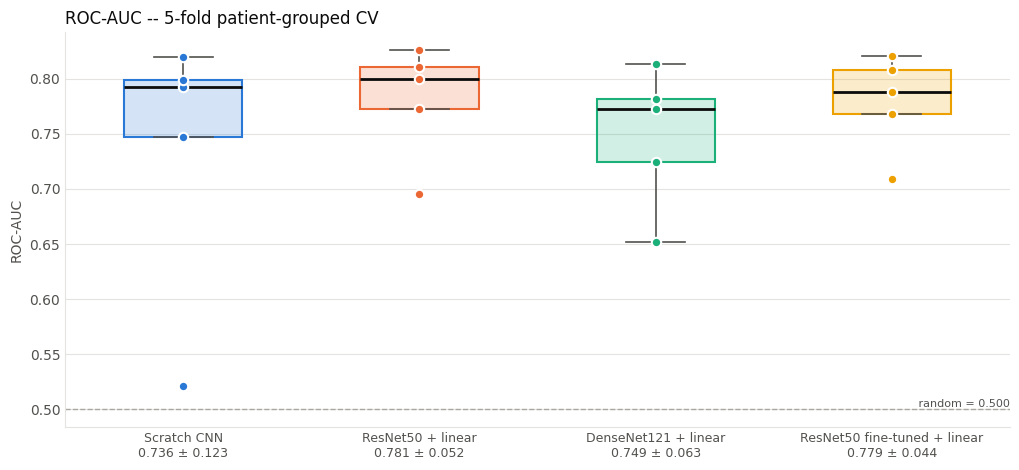

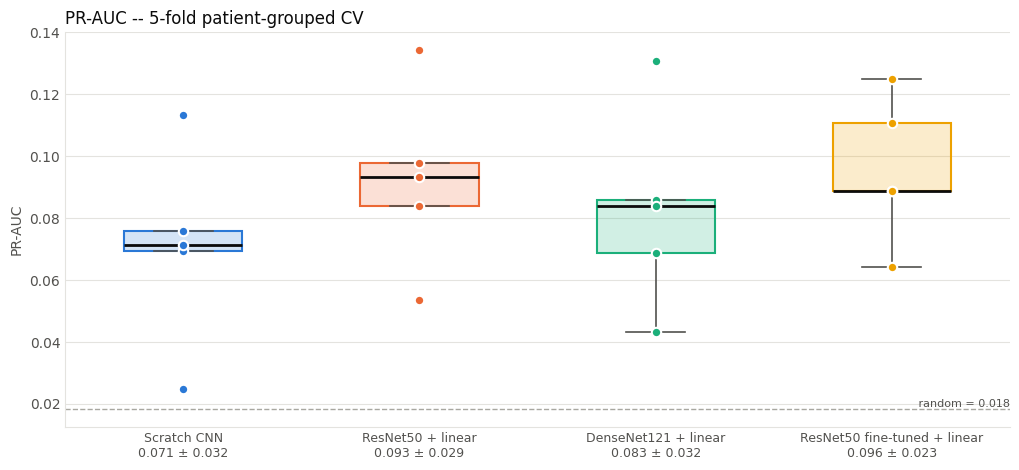

saved figures to cv_base_models_figures/


In [16]:
MODEL_COLORS = {'Scratch CNN': '#2a78d6', 'ResNet50 + linear': '#eb6834',
                'DenseNet121 + linear': '#1baf7a', 'ResNet50 fine-tuned + linear': '#eda100'}
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
FIG_DIR = 'cv_base_models_figures'
os.makedirs(FIG_DIR, exist_ok=True)

for metric, label, baseline in [('roc_auc', 'ROC-AUC', 0.5), ('pr_auc', 'PR-AUC', y.mean())]:
    values = [results.loc[results['model'] == m, metric].to_numpy() for m in MODEL_ORDER]
    fig, ax = plt.subplots(figsize=(2.2 * len(MODEL_ORDER) + 1.5, 4.8))
    bp = ax.boxplot(values, positions=range(len(MODEL_ORDER)), widths=0.5, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=INK_MUTED, linewidth=1.2),
                    capprops=dict(color=INK_MUTED, linewidth=1.2), boxprops=dict(linewidth=1.5))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m] + '33')
        patch.set_edgecolor(MODEL_COLORS[m])
    for pos, (vals, m) in enumerate(zip(values, MODEL_ORDER)):
        ax.scatter(np.full(len(vals), pos), vals, s=46, color=MODEL_COLORS[m], edgecolor='white',
                   linewidth=1.5, zorder=3)
    ax.axhline(baseline, color='#a8a7a0', linestyle='--', linewidth=1)
    ax.text(len(MODEL_ORDER) - 0.5, baseline, f' random = {baseline:.3f}', va='bottom', ha='right',
            fontsize=8, color=INK_MUTED)
    ax.set_xticks(range(len(MODEL_ORDER)),
                  [f'{m}\n{v.mean():.3f} ± {v.std(ddof=1):.3f}' for m, v in zip(MODEL_ORDER, values)],
                  fontsize=9, color=INK)
    ax.set_ylabel(label, color=INK_MUTED)
    ax.set_title(f'{label} -- {N_FOLDS}-fold patient-grouped CV', color=INK, fontsize=12, loc='left')
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'cv_base_models_{metric}.png')
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()

if os.path.isdir(DRIVE_DIR):
    shutil.copytree(FIG_DIR, os.path.join(DRIVE_DIR, FIG_DIR), dirs_exist_ok=True)
    shutil.copy('cv_base_models_summary.csv', os.path.join(DRIVE_DIR, 'cv_base_models_summary.csv'))
print(f'saved figures to {FIG_DIR}/')